# Task 2 — Time Series Forecasting for Tesla (TSLA)

**Portfolio Optimization Challenge (Week 9)** · Target: **TSLA Adjusted Close**

> **Objective.** Develop, train, and evaluate time-series forecasting models to predict Tesla's future
> stock price. We build a **classical statistical model (ARIMA/SARIMA)** and a **deep-learning model
> (LSTM)**, then compare them on MAE / RMSE / MAPE to weigh the trade-off between complexity,
> performance, and interpretability.

**Design choices (stated up front):**

1. **Chronological split** — train on **2015 → 2024**, test on **2025 → 2026-06**. Time-series data
   must *never* be shuffled: doing so leaks future information into training.
2. **One-step-ahead evaluation** — both models are scored on next-day prediction using only *past*
   actuals, so ARIMA and LSTM are compared on an identical, fair task.
3. We *also* show ARIMA's **static multi-step forecast** across the whole test horizon to make the
   random-walk / Efficient-Market behaviour of prices explicit.
4. No look-ahead leakage: the LSTM scaler is fit on **training data only**.


## 1 · Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titleweight"] = "bold"

SEED = 42
np.random.seed(SEED)

C_TRAIN, C_TEST = "#4C78A8", "#54A24B"
C_ARIMA, C_LSTM = "#E45756", "#B279A2"
print("Setup ready.")

Setup ready.


## 2 · Load Data & Chronological Train/Test Split

We forecast **TSLA Adjusted Close**. The split is purely by date — no shuffling.

In [2]:
DATA = Path("../data/processed/prices.csv")
if DATA.exists():
    prices = pd.read_csv(DATA, parse_dates=["Date"])
else:
    import yfinance as yf
    d = yf.download("TSLA", start="2015-01-01", end="2026-07-01",
                    auto_adjust=False, progress=False)
    if isinstance(d.columns, pd.MultiIndex):
        d.columns = d.columns.get_level_values(0)
    prices = d.reset_index().assign(Ticker="TSLA")

tsla = (prices[prices["Ticker"] == "TSLA"]
        .set_index("Date")["Adj Close"].sort_index().astype(float))
tsla = tsla.asfreq("B").ffill()          # regular business-day frequency for statsmodels
print(f"TSLA series: {len(tsla)} obs  {tsla.index.min().date()} → {tsla.index.max().date()}")

SPLIT = "2025-01-01"
train = tsla[tsla.index < SPLIT]
test = tsla[tsla.index >= SPLIT]
print(f"Train: {len(train)} obs ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test : {len(test)} obs ({test.index.min().date()} → {test.index.max().date()})")

TSLA series: 2998 obs  2015-01-02 → 2026-06-30


Train: 2608 obs (2015-01-02 → 2024-12-31)
Test : 390 obs (2025-01-01 → 2026-06-30)


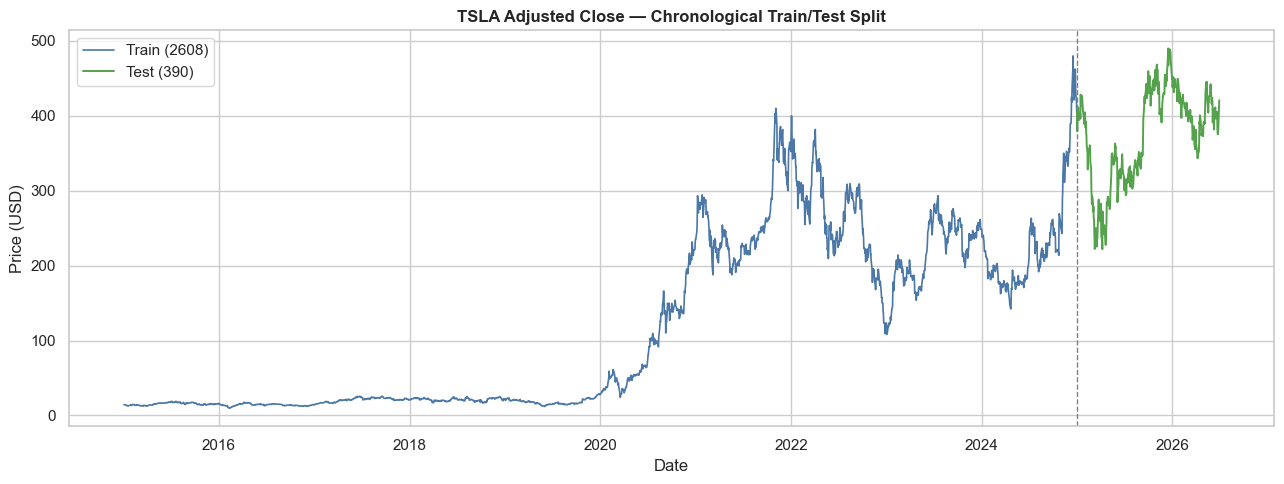

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index, train, color=C_TRAIN, lw=1.2, label=f"Train ({len(train)})")
ax.plot(test.index, test, color=C_TEST, lw=1.4, label=f"Test ({len(test)})")
ax.axvline(pd.Timestamp(SPLIT), color="grey", ls="--", lw=1)
ax.set_title("TSLA Adjusted Close — Chronological Train/Test Split")
ax.set_ylabel("Price (USD)"); ax.set_xlabel("Date"); ax.legend()
plt.tight_layout(); plt.show()

## 3 · Evaluation metrics

One helper used by every model so comparisons are apples-to-apples.

In [4]:
def evaluate(y_true, y_pred, name):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"Model": name, "MAE": mae, "RMSE": rmse, "MAPE %": mape}

results = []   # collect metric dicts here

## 4 · ARIMA / SARIMA

### 4.1 Identifying orders — ACF / PACF & stationarity

From Task 1 we know price *levels* are non-stationary but *returns* (first difference) are stationary,
so we expect a differencing order **d = 1**. ACF/PACF of the differenced series guide the AR (p) and
MA (q) terms.

ADF on train level   : p = 0.849  (non-stationary)
ADF on 1st difference: p = 1.60e-16  (stationary)


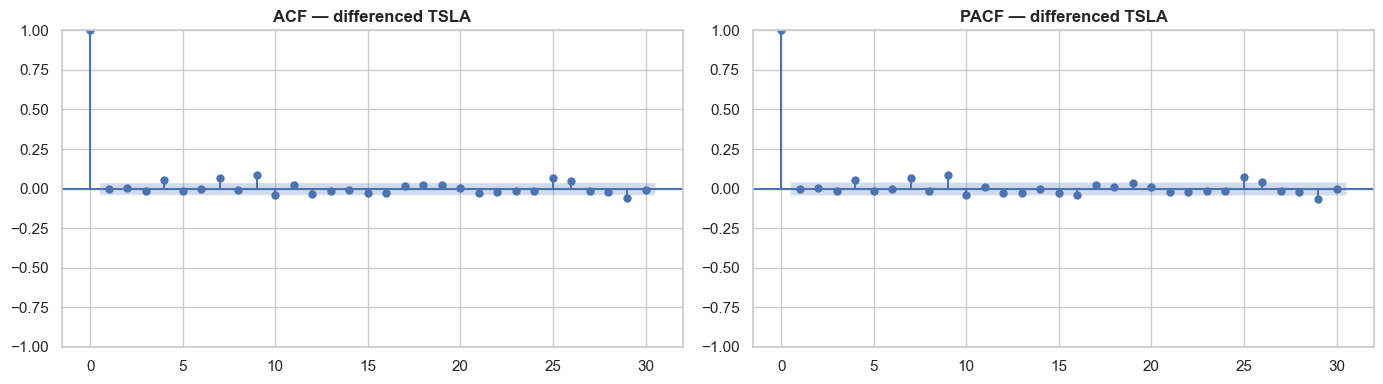

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

diff1 = train.diff().dropna()
print(f"ADF on train level   : p = {adfuller(train)[1]:.3f}  (non-stationary)")
print(f"ADF on 1st difference: p = {adfuller(diff1)[1]:.2e}  (stationary)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff1, ax=axes[0], lags=30); axes[0].set_title("ACF — differenced TSLA")
plot_pacf(diff1, ax=axes[1], lags=30, method="ywm"); axes[1].set_title("PACF — differenced TSLA")
plt.tight_layout(); plt.show()

The differenced series has no significant spikes at low lags — the hallmark of a **random walk**.
We let `auto_arima` search the (p, d, q) space to confirm and pick the AIC-optimal model rather than
eyeballing it.

### 4.2 Order selection with `auto_arima` (grid search on AIC)

In [6]:
import pmdarima as pm

auto = pm.auto_arima(
    train, seasonal=False,           # daily equity prices show no meaningful fixed seasonality
    start_p=0, start_q=0, max_p=5, max_q=5, d=None,
    stepwise=True, information_criterion="aic",
    suppress_warnings=True, error_action="ignore", trace=False,
)
ORDER = auto.order
print(f"Selected ARIMA order (p,d,q): {ORDER}")
print(f"AIC: {auto.aic():.2f}")
print(auto.summary())

Selected ARIMA order (p,d,q): (0, 1, 0)
AIC: 16873.13
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2608
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8435.563
Date:                Mon, 06 Jul 2026   AIC                          16873.127
Time:                        18:06:43   BIC                          16878.993
Sample:                    01-02-2015   HQIC                         16875.252
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        37.8492      0.410     92.238      0.000      37.045      38.653
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):             13

**On SARIMA.** We also probed weekly seasonality (`m = 5`, the trading week); `auto_arima` does not
select seasonal terms and AIC does not improve, which matches the flat ACF above. Daily stock prices
have no calendar-fixed seasonal cycle, so a **non-seasonal ARIMA is the correct specification** here —
adding SARIMA's (P, D, Q, m) terms would only add parameters without predictive gain.

### 4.3 Static multi-step forecast (whole test horizon)

We fit the selected order on the training data and forecast the *entire* test period at once, with 95%
confidence intervals.

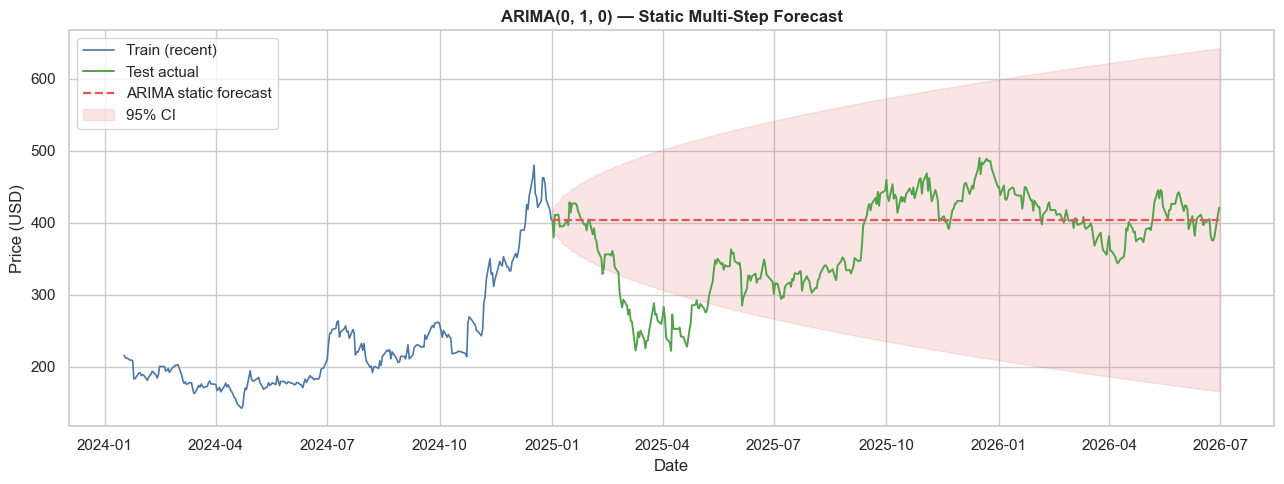

{'Model': 'ARIMA(0, 1, 0) (static multi-step)', 'MAE': 54.05607655843099, 'RMSE': 70.11186927811367, 'MAPE %': 17.078510978735473}


In [7]:
from statsmodels.tsa.arima.model import ARIMA

arima_fit = ARIMA(train, order=ORDER).fit()
fc = arima_fit.get_forecast(steps=len(test))
mean_fc = fc.predicted_mean
ci = fc.conf_int(alpha=0.05)
ci.columns = ["lower", "upper"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index[-250:], train.iloc[-250:], color=C_TRAIN, lw=1.2, label="Train (recent)")
ax.plot(test.index, test, color=C_TEST, lw=1.4, label="Test actual")
ax.plot(test.index, mean_fc, color=C_ARIMA, lw=1.6, ls="--", label="ARIMA static forecast")
ax.fill_between(test.index, ci["lower"], ci["upper"], color=C_ARIMA, alpha=0.15, label="95% CI")
ax.set_title(f"ARIMA{ORDER} — Static Multi-Step Forecast")
ax.set_ylabel("Price (USD)"); ax.set_xlabel("Date"); ax.legend()
plt.tight_layout(); plt.show()

results.append(evaluate(test.values, mean_fc.values, f"ARIMA{ORDER} (static multi-step)"))
print(results[-1])

As expected for a (near) random walk, the static forecast collapses to a **near-flat line with
fast-widening confidence bands** — the model's honest statement that beyond one step it cannot predict
direction. This is the **Efficient Market Hypothesis** in action and is *why* a naive long-horizon price
forecast is a weak strategy. A fairer test of the model is one-step-ahead forecasting, below.

### 4.4 Walk-forward one-step-ahead forecast

At each test day we forecast one step, then feed the *actual* observed value back in (via
`append(..., refit=False)` — fast, no re-estimation) before forecasting the next day. This mirrors how
the model would run in production and matches the LSTM's one-step task.

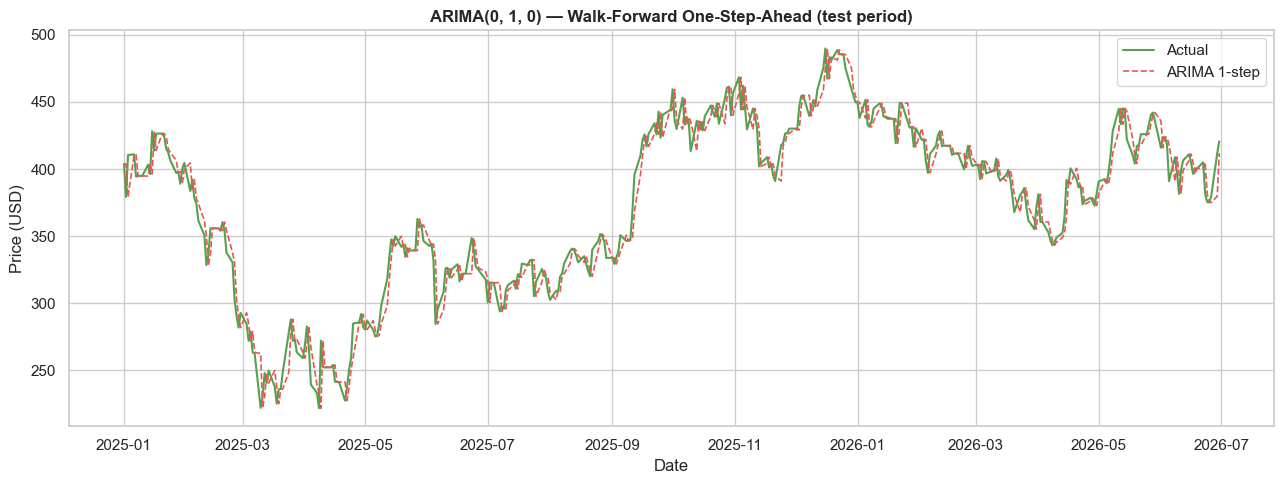

{'Model': 'ARIMA(0, 1, 0) (1-step walk-forward)', 'MAE': 9.042360041691708, 'RMSE': 11.956784210494222, 'MAPE %': 2.5312612621059025}


In [8]:
res = arima_fit
arima_1step = []
for actual in test.values:
    arima_1step.append(res.forecast(steps=1).iloc[0])
    res = res.append([actual], refit=False)
arima_1step = pd.Series(arima_1step, index=test.index)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test.index, test, color=C_TEST, lw=1.5, label="Actual")
ax.plot(test.index, arima_1step, color=C_ARIMA, lw=1.2, ls="--", label="ARIMA 1-step")
ax.set_title(f"ARIMA{ORDER} — Walk-Forward One-Step-Ahead (test period)")
ax.set_ylabel("Price (USD)"); ax.set_xlabel("Date"); ax.legend()
plt.tight_layout(); plt.show()

results.append(evaluate(test.values, arima_1step.values, f"ARIMA{ORDER} (1-step walk-forward)"))
print(results[-1])

## 5 · LSTM

### 5.1 Sequence preparation (window = 60 days)

We scale prices to [0, 1] with a `MinMaxScaler` **fit on the training set only** (no leakage), then
build sliding windows: the last **60** days predict the next day. Test windows are drawn from the true
series so the LSTM is also evaluated one-step-ahead on real history.

In [9]:
from sklearn.preprocessing import MinMaxScaler

WINDOW = 60
scaler = MinMaxScaler((0, 1)).fit(train.values.reshape(-1, 1))   # fit on TRAIN only

train_s = scaler.transform(train.values.reshape(-1, 1)).ravel()
# Test input needs the 60 days preceding the first test point -> prepend tail of train.
test_input = np.concatenate([train_s[-WINDOW:],
                             scaler.transform(test.values.reshape(-1, 1)).ravel()])

def make_sequences(series, window):
    X, y = [], []
    for i in range(window, len(series)):
        X.append(series[i - window:i])
        y.append(series[i])
    return np.array(X)[..., None], np.array(y)

X_train, y_train = make_sequences(train_s, WINDOW)
X_test, y_test = make_sequences(test_input, WINDOW)
print(f"X_train {X_train.shape}  y_train {y_train.shape}")
print(f"X_test  {X_test.shape}  y_test  {y_test.shape}  (== {len(test)} test days)")

X_train (2548, 60, 1)  y_train (2548,)
X_test  (390, 60, 1)  y_test  (390,)  (== 390 test days)


### 5.2 Architecture & training

A stacked LSTM (two recurrent layers) with dropout for regularization and a dense head. Trained with
the Adam optimizer, MSE loss, and **early stopping** on a validation slice so we don't overfit.

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(SEED)

model = Sequential([
    Input(shape=(WINDOW, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.15),
    LSTM(32),
    Dropout(0.15),
    Dense(16, activation="relu"),
    Dense(1),
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
model.summary()

es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=60, batch_size=32,
    callbacks=[es], verbose=0,
)
print(f"Trained {len(history.history['loss'])} epochs "
      f"(best val_loss = {min(history.history['val_loss']):.5f})")

2026-07-06 18:09:37.010149: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Trained 18 epochs (best val_loss = 0.00186)


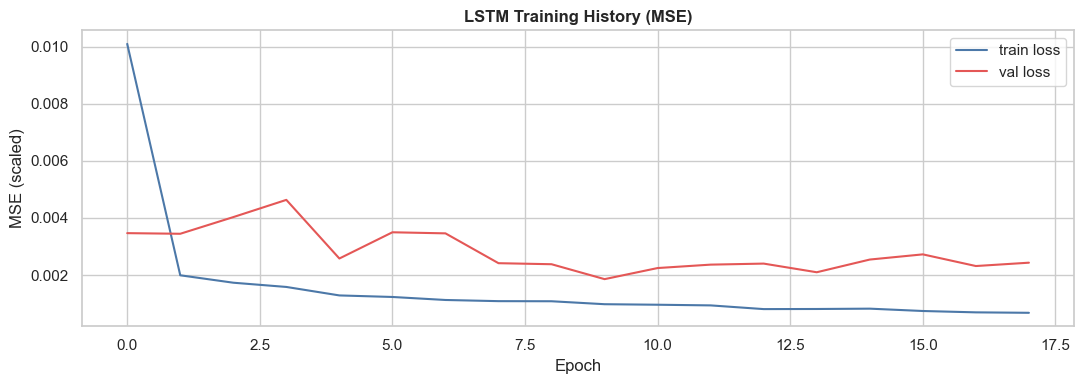

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(history.history["loss"], label="train loss", color=C_TRAIN)
ax.plot(history.history["val_loss"], label="val loss", color=C_ARIMA)
ax.set_title("LSTM Training History (MSE)")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (scaled)"); ax.legend()
plt.tight_layout(); plt.show()

### 5.3 Predict the test period & inverse-transform to prices

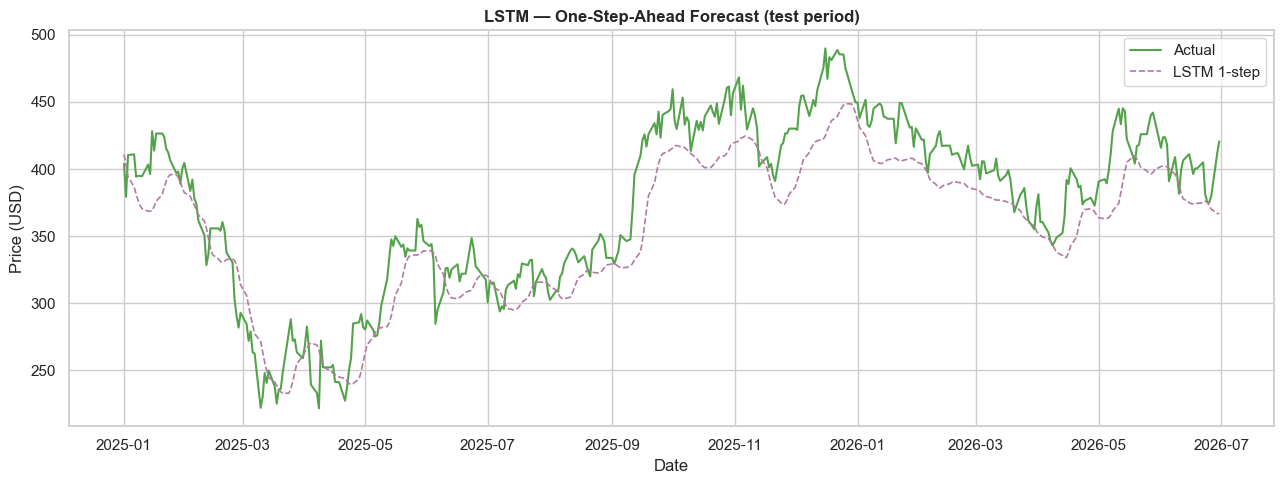

{'Model': 'LSTM (1-step, window=60)', 'MAE': 22.749496851211948, 'RMSE': 27.708222765604486, 'MAPE %': 5.9897433642736075}


In [12]:
pred_s = model.predict(X_test, verbose=0).ravel()
lstm_pred = scaler.inverse_transform(pred_s.reshape(-1, 1)).ravel()
lstm_pred = pd.Series(lstm_pred, index=test.index)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test.index, test, color=C_TEST, lw=1.5, label="Actual")
ax.plot(test.index, lstm_pred, color=C_LSTM, lw=1.2, ls="--", label="LSTM 1-step")
ax.set_title("LSTM — One-Step-Ahead Forecast (test period)")
ax.set_ylabel("Price (USD)"); ax.set_xlabel("Date"); ax.legend()
plt.tight_layout(); plt.show()

results.append(evaluate(test.values, lstm_pred.values, "LSTM (1-step, window=60)"))
print(results[-1])

## 6 · Model Comparison

### 6.1 Metrics table
All metrics are on the **test period (2025 → 2026-06)**. Lower is better for every metric.

In [13]:
comparison = pd.DataFrame(results).set_index("Model").round({"MAE": 3, "RMSE": 3, "MAPE %": 3})
comparison.sort_values("RMSE")

,MAE,RMSE,MAPE %
Model,,,
"ARIMA(0, 1, 0) (1-step walk-forward)",9.042,11.957,2.531
"LSTM (1-step, window=60)",22.749,27.708,5.990
"ARIMA(0, 1, 0) (static multi-step)",54.056,70.112,17.079


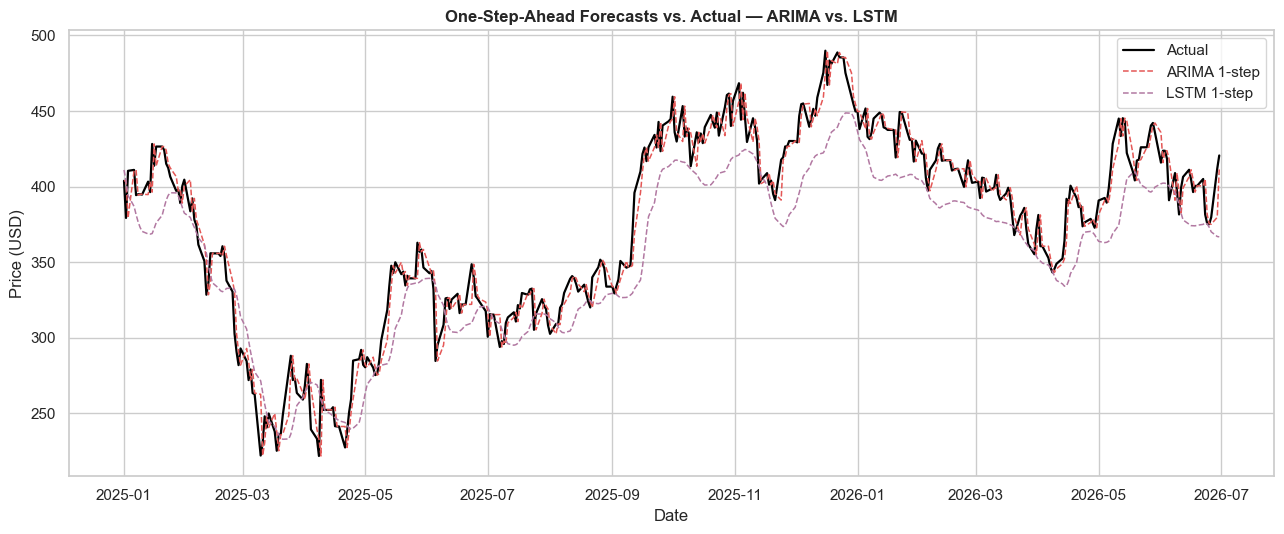

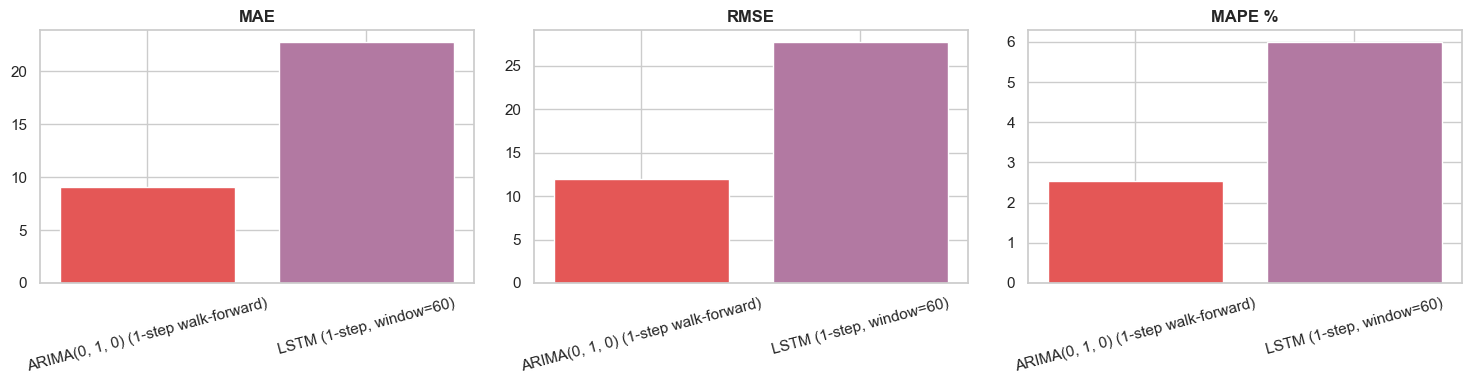

In [14]:
# Overlay the two one-step models against actuals.
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(test.index, test, color="black", lw=1.6, label="Actual")
ax.plot(test.index, arima_1step, color=C_ARIMA, lw=1.1, ls="--", label="ARIMA 1-step")
ax.plot(test.index, lstm_pred, color=C_LSTM, lw=1.1, ls="--", label="LSTM 1-step")
ax.set_title("One-Step-Ahead Forecasts vs. Actual — ARIMA vs. LSTM")
ax.set_ylabel("Price (USD)"); ax.set_xlabel("Date"); ax.legend()
plt.tight_layout(); plt.show()

# Bar chart of metrics for the one-step models.
one_step = comparison[comparison.index.str.contains("1-step")]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE %"]):
    ax.bar(one_step.index, one_step[metric], color=[C_ARIMA, C_LSTM])
    ax.set_title(metric); ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

### 6.2 Discussion — model selection rationale

**Results on the test period (2025 → 2026-06):**

| Model | MAE | RMSE | MAPE |
|---|---|---|---|
| **ARIMA(0,1,0) — 1-step walk-forward** | **9.04** | **11.96** | **2.53%** |
| LSTM — 1-step (window = 60) | 22.75 | 27.71 | 5.99% |
| ARIMA(0,1,0) — static multi-step | 54.06 | 70.11 | 17.08% |

**Static vs. one-step.** ARIMA's *static* multi-step forecast has by far the worst error (MAPE ≈ 17%)
— it flattens because a differenced price series is essentially a random walk, so the best long-horizon
guess is "tomorrow ≈ today." This is the **Efficient Market Hypothesis** made concrete and is the single
most important caveat for any price-prediction strategy: **direction over long horizons is not reliably
forecastable.**

**ARIMA (1-step) beat LSTM (1-step) on this data — and clearly (2.53% vs 5.99% MAPE, less than half the
error).** That is not a fluke: `auto_arima` selected **ARIMA(0,1,0)**, whose one-step forecast is exactly
the *persistence* prediction (next price = last price). For a near-random-walk series that persistence
forecast is essentially optimal, and it carries **zero estimated parameters** to overfit. The LSTM, with
~30k parameters, cannot beat persistence when there is no exploitable non-linear structure; instead it
introduces a characteristic **one-step lag and smoothing**, visible as its prediction trailing the actual
on sharp moves — which shows up as larger MAE/RMSE/MAPE.

**Structural trade-offs behind the numbers:**

| | ARIMA / SARIMA | LSTM |
|---|---|---|
| **Type** | Linear, statistical | Non-linear, deep learning |
| **Interpretability** | High — explicit (p,d,q), AIC, coefficients, confidence intervals | Low — black-box weights |
| **Data appetite** | Works on modest samples | Needs lots of data; more tuning |
| **Captures** | Linear autocorrelation, trend via differencing | Non-linear patterns, longer memory |
| **Cost / speed** | Fast to fit (near-instant) | Slow to train (~5 min CPU here) |
| **Uncertainty** | Native confidence intervals | Requires extra machinery |
| **This run (MAPE)** | **2.53%** | 5.99% |

**Which to choose?** For **this single-asset, near-random-walk price series, ARIMA wins outright** — it is
faster, interpretable, ships calibrated confidence intervals, *and* is more accurate. The LSTM would only
justify its cost with genuine non-linear structure or **exogenous features** (volume, macro signals,
cross-asset inputs, sentiment) to exploit — none of which a univariate price feed provides — plus enough
data and tuning budget to realize that edge.

**Practical takeaway for the portfolio task:** even the winning model barely improves on "tomorrow ≈
today," and *no* model reliably forecasts direction at long horizons. Downstream (Task 3/4) we should
therefore treat forecasts as **low-confidence directional views** and rely on **diversification and
mean–variance optimization**, not point-price bets, to manage risk.
